In [1]:
import sys
sys.path.append('../../scripts')
import utils as util
import stock_indicators as si
import plot as plot
import text_analyzer
import correlation_analyzer as ca

In [2]:
stockutils = util.StockUtils
preprocesser = util.DataPreprocessor

Load the Data.

In [3]:
data = stockutils.load_stock_data('../../data/Stock Data/AAPL.csv')
data.head(5)

,Ticker,Date,Close,High,Low,Open,Volume
0,AAPL,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,AAPL,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,AAPL,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,AAPL,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,AAPL,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [4]:
preprocesser.explore_data(data)

Shape of the data: (3774, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ticker  3774 non-null   object 
 1   Date    3774 non-null   object 
 2   Close   3774 non-null   float64
 3   High    3774 non-null   float64
 4   Low     3774 non-null   float64
 5   Open    3774 non-null   float64
 6   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 206.5+ KB
Info of the data: None


Reorder the columns and keep the ticker symbol.

In [5]:
data = data[['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

In [6]:
stockutils.index_by_date(data)
data.head()

,Ticker,Open,High,Low,Close,Volume
Date,,,,,,
2009-01-02,AAPL,2.575630,2.730385,2.554037,2.721686,746015200
2009-01-05,AAPL,2.794266,2.884539,2.780469,2.836553,1181608400
2009-01-06,AAPL,2.877641,2.914229,2.770872,2.789767,1289310400
2009-01-07,AAPL,2.753477,2.774170,2.706990,2.729484,753048800
2009-01-08,AAPL,2.712090,2.793666,2.700393,2.780169,673500800


In [7]:
data.describe()

,Open,High,Low,Close,Volume
count,3774.000000,3774.000000,3774.000000,3774.000000,3.774000e+03
mean,53.801628,54.383801,53.247465,53.841169,2.640640e+08
std,55.009182,55.627235,54.440128,55.064042,2.345629e+08
min,2.380989,2.459265,2.345299,2.345299,2.404830e+07
25%,15.007580,15.183043,14.901886,15.050355,9.581845e+07
50%,27.010205,27.168844,26.836844,26.975808,1.667348e+08
75%,74.127927,75.252383,73.553555,74.664204,3.777410e+08
max,196.167437,197.752460,195.156944,196.256592,1.880998e+09


In [8]:
plotter = plot.Plot

#### Analysis Indicators with TA-Lib

In [9]:
technical_indicators = si.IndicatorCalculator

In [10]:
technical_indicators.calculate_technical_indicators(data)
data.tail(5)

,Ticker,Open,High,Low,Close,Volume,SMA_20,SMA_50,EMA_20,EMA_50,RSI_14,MACD,MACDSignal,MACD_hist
Date,,,,,,,,,,,,,,
2023-12-22,AAPL,193.353962,193.581821,191.164647,191.788757,37149600,191.856618,183.572859,191.856618,183.572859,54.672784,2.633141,3.235256,-0.602115
2023-12-26,AAPL,191.798670,192.076049,191.025969,191.243912,28919300,192.018094,183.858864,192.018094,183.858864,53.090049,2.304751,3.049155,-0.744404
2023-12-27,AAPL,190.689158,191.689703,189.302247,191.342972,48087700,192.154308,184.149424,192.154308,184.149424,53.354446,2.029104,2.845145,-0.816041
2023-12-28,AAPL,192.323710,192.838849,191.362784,191.768951,34049900,192.362839,184.479567,192.362839,184.479567,54.540999,1.823998,2.640915,-0.816918
2023-12-29,AAPL,192.085953,192.581275,189.936256,190.728775,42672100,192.490633,184.814828,192.490633,184.814828,51.121347,1.559539,2.424640,-0.865101


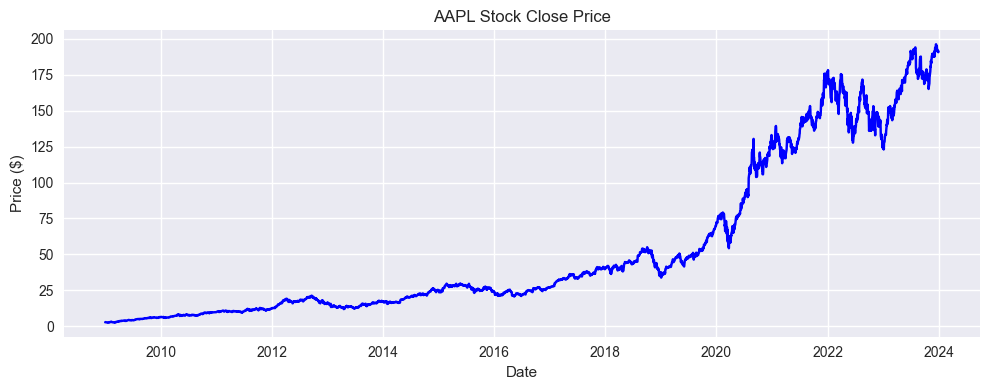

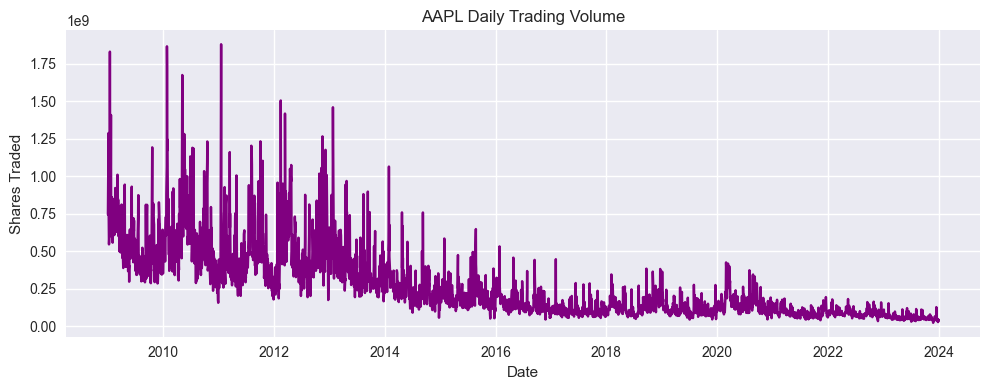

In [11]:
plotter.plot_stock_price(data)

In [12]:
plotter.plot_stock_mva(data)

In [13]:
plotter.plot_ema(data)

In [14]:
plotter.plot_rsi(data)

In [15]:
plotter.plot_macd(data)

### Correlation Analysis

In [16]:
headline_data = util.load_data('../../data/cleaned/cleaned_news_data.csv')

After loading the data, we filter the headlines by stock. And then normalize the dates as we did previously.

In [17]:
headline_data = stockutils.filter_data_by_stock(headline_data, 'AAPL')
preprocesser.convert_date_dtype(headline_data)
headline_data.head(5)

Converted 'date' dtype: datetime64[ns, UTC]


,headline,url,publisher,date,stock
6680,Tech Stocks And FAANGS Strong Again To Start D...,https://www.benzinga.com/government/20/06/1622...,JJ Kinahan,2020-06-10 15:33:26+00:00,AAPL
6681,10 Biggest Price Target Changes For Wednesday,https://www.benzinga.com/analyst-ratings/price...,Lisa Levin,2020-06-10 12:14:08+00:00,AAPL
6682,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",https://www.benzinga.com/short-sellers/20/06/1...,Benzinga Newsdesk,2020-06-10 11:53:47+00:00,AAPL
6683,"Deutsche Bank Maintains Buy on Apple, Raises P...",https://www.benzinga.com/news/20/06/16219873/d...,Benzinga Newsdesk,2020-06-10 11:19:25+00:00,AAPL
6684,Apple To Let Users Trade In Their Mac Computer...,https://www.benzinga.com/news/20/06/16218697/a...,Neer Varshney,2020-06-10 10:27:11+00:00,AAPL


In [18]:
textanaysis = text_analyzer.TextAnalyzer

Here we only keep the relevant columns for the correlation analysis.

In [19]:
headline_with_sentiment = textanaysis.analyze_headline_sentiment(headline_data)
headline_with_sentiment['date'] = headline_with_sentiment ['date'].dt.date

headlines_with_sentiment= headline_with_sentiment[['date', 'headline', 'stock', 'sentiment', 'sentiment_score']].copy()

In [20]:
combined_data = stockutils.merge_sentiment_with_stock(headlines_with_sentiment, data)
combined_data.head()

,headline,stock,sentiment,sentiment_score,Close,Volume
date,,,,,,
2020-06-10,Tech Stocks And FAANGS Strong Again To Start D...,AAPL,positive,0.5574,85.566071,166651600.0
2020-06-10,10 Biggest Price Target Changes For Wednesday,AAPL,neutral,0.0000,85.566071,166651600.0
2020-06-10,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",AAPL,positive,0.2023,85.566071,166651600.0
2020-06-10,"Deutsche Bank Maintains Buy on Apple, Raises P...",AAPL,neutral,0.0000,85.566071,166651600.0
2020-06-10,Apple To Let Users Trade In Their Mac Computer...,AAPL,positive,0.3818,85.566071,166651600.0


Update all columns to be in lowercase.

In [21]:
combined_data_lowercase = stockutils.lowercase_columns(combined_data)
combined_data_lowercase.head(5)

,headline,stock,sentiment,sentiment_score,close,volume
date,,,,,,
2020-06-10,Tech Stocks And FAANGS Strong Again To Start D...,AAPL,positive,0.5574,85.566071,166651600.0
2020-06-10,10 Biggest Price Target Changes For Wednesday,AAPL,neutral,0.0000,85.566071,166651600.0
2020-06-10,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",AAPL,positive,0.2023,85.566071,166651600.0
2020-06-10,"Deutsche Bank Maintains Buy on Apple, Raises P...",AAPL,neutral,0.0000,85.566071,166651600.0
2020-06-10,Apple To Let Users Trade In Their Mac Computer...,AAPL,positive,0.3818,85.566071,166651600.0


#### Daily Returns

In [22]:
data_with_daily_returns = technical_indicators.calculate_daily_returns(combined_data_lowercase)
data_with_daily_returns.head()

/Users/hazel/Desktop/Self Study/kiam8/kaim-week-1/notebooks/stocks/../../scripts/stock_indicators.py:47: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



,headline,stock,sentiment,sentiment_score,close,volume,daily_returns
date,,,,,,,
2020-06-10,10 Biggest Price Target Changes For Wednesday,AAPL,neutral,0.0000,85.566071,166651600.0,0.0
2020-06-10,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",AAPL,positive,0.2023,85.566071,166651600.0,0.0
2020-06-10,"Deutsche Bank Maintains Buy on Apple, Raises P...",AAPL,neutral,0.0000,85.566071,166651600.0,0.0
2020-06-10,Apple To Let Users Trade In Their Mac Computer...,AAPL,positive,0.3818,85.566071,166651600.0,0.0
2020-06-10,Big Tech Reaches New Record Heights At The Sto...,AAPL,positive,0.0516,85.566071,166651600.0,0.0


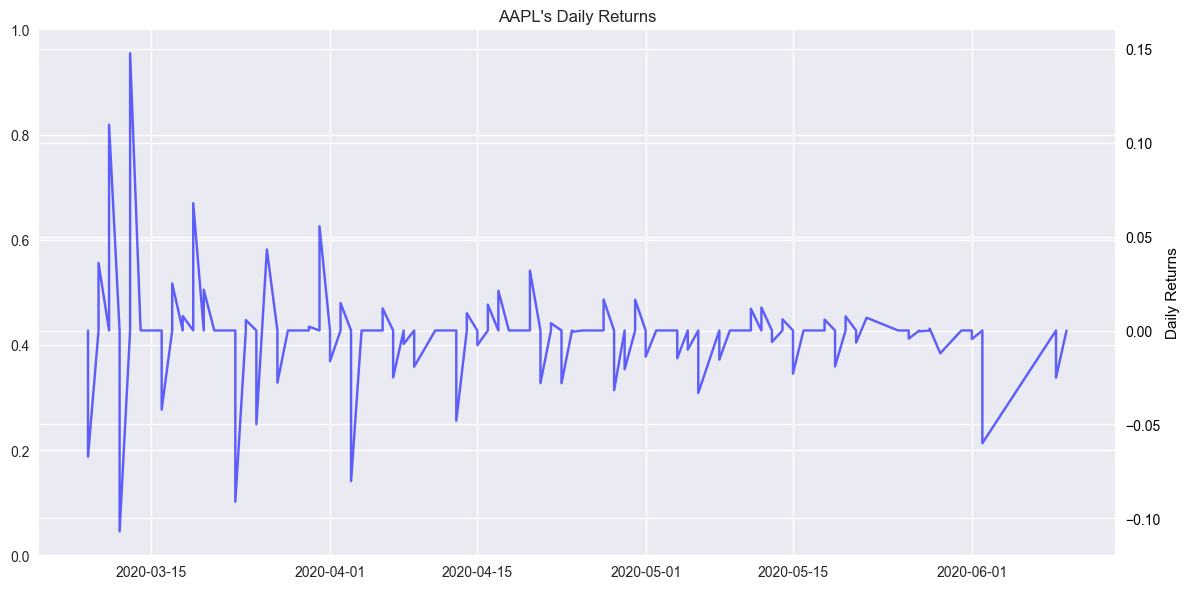

In [23]:
plotter.plot_daily_returns(data_with_daily_returns)

In [24]:
correlation_analysis = ca.CorrelationAnalysis

In [25]:
correlation_analysis.sentiment_correlation_analysis(data_with_daily_returns)

Correlation between sentiment_score and daily_returns is 0.0625
Correlation between sentiment_score and close is 0.0201


(np.float64(0.06247755639257075), np.float64(0.020063998405865098))

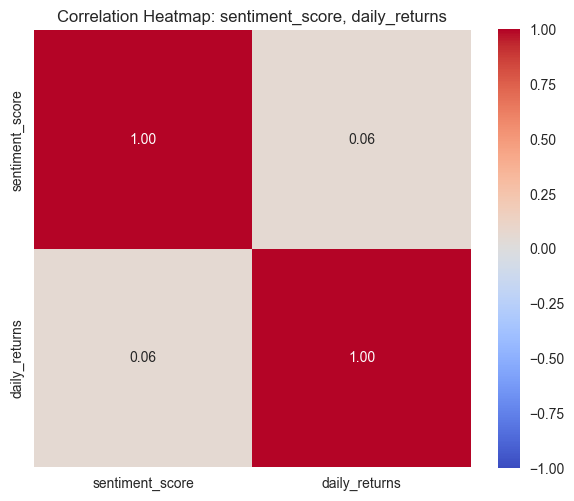

In [26]:
plotter.correlation_heatmap(data_with_daily_returns, ['sentiment_score', 'daily_returns' ])

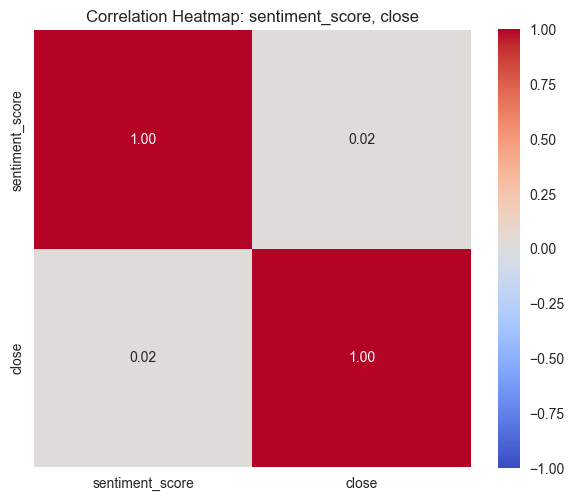

In [27]:
plotter.correlation_heatmap(data_with_daily_returns, ['sentiment_score', 'close' ])

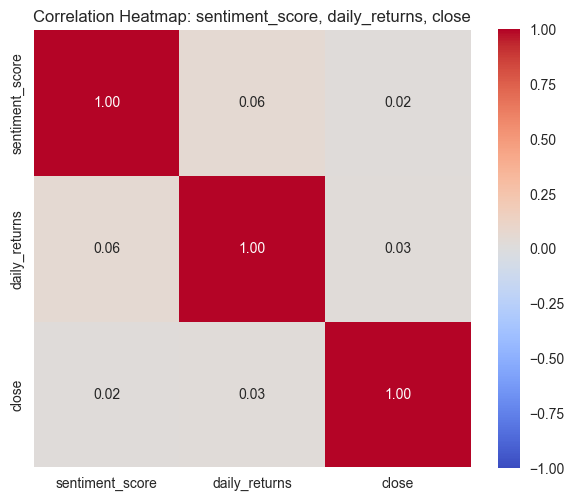

In [28]:
plotter.correlation_heatmap(data_with_daily_returns, ['sentiment_score', 'daily_returns', 'close' ])

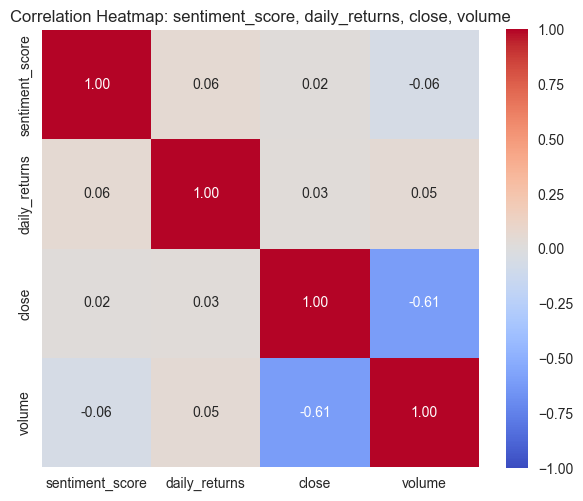

In [29]:
plotter.correlation_heatmap(data_with_daily_returns, ['sentiment_score', 'daily_returns', 'close', 'volume' ])